# Complexity Distribution by Indicator (Camera-Ready)

This notebook builds publication-ready boxplots of `complexity_index` by indicator
using active-category CSV files from `Version 2/complexity`.

Exports are generated in PNG, SVG, and PDF for three variants:
- `with_title`
- `without_title`
- `clean_minimal`


## 1) Imports and Style


In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})


## 2) Configuration


In [2]:
PROJECT_ROOT = Path.cwd()

CANDIDATE_COMPLEXITY_DIRS = [
    PROJECT_ROOT / "complexity",
    PROJECT_ROOT / "Version 2" / "complexity",
    PROJECT_ROOT.parent / "Version 2" / "complexity",
]

COMPLEXITY_DIR = next((p.resolve() for p in CANDIDATE_COMPLEXITY_DIRS if p.exists()), CANDIDATE_COMPLEXITY_DIRS[0].resolve())
OUTPUT_DIR = COMPLEXITY_DIR.parent / "paper_figures" / "complexity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_FILES = {
    "Relevance": "boxplot_data__complexity_active__Relevance.csv",
    "Interpretability": "boxplot_data__complexity_active__Interpretability.csv",
    "Completeness": "boxplot_data__complexity_active__Completeness.csv",
    "Differential Regime": "boxplot_data__complexity_active__Differential_Regime.csv",
    "Discretionality": "boxplot_data__complexity_active__Discretionality.csv",
}

DISPLAY_NAMES = {
    "Relevance": "Relevance",
    "Interpretability": "Interpretation",
    "Completeness": "Completeness",
    "Differential Regime": "Differential Regime",
    "Discretionality": "Discretion",
}

ORDER = [
    "Relevance",
    "Interpretability",
    "Completeness",
    "Differential Regime",
    "Discretionality",
]

FIGSIZE = (7.6, 4.5)
RNG_SEED = 42
EXPORT_DPI = 400

# Project palette family (green-forward, print-safe)
PALETTE = {
    "Relevance": "#4CAF78",
    "Interpretability": "#4CAF78",
    "Completeness": "#4CAF78",
    "Differential Regime": "#4CAF78",
    "Discretionality": "#4CAF78",
}
BOX_EDGE = "#2F2F2F"
MEDIAN_COLOR = "#1F1F1F"
POINT_COLOR = "#4A4A4A"

STYLE_VARIANTS = [
    {"name": "with_title", "show_title": True, "show_points": True},
    {"name": "without_title", "show_title": False, "show_points": True},
    {"name": "clean_minimal", "show_title": False, "show_points": False},
]

print("COMPLEXITY_DIR:", COMPLEXITY_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


COMPLEXITY_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\complexity
OUTPUT_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity


## 3) Load and Prepare Data


In [3]:
def load_indicator_data() -> pd.DataFrame:
    parts = []
    for key, file_name in TARGET_FILES.items():
        path = COMPLEXITY_DIR / file_name
        if not path.exists():
            raise FileNotFoundError(f"Missing file: {path}")

        d = pd.read_csv(path)
        required = {"complexity_index"}
        missing = required - set(d.columns)
        if missing:
            raise ValueError(f"Missing columns in {path.name}: {sorted(missing)}")

        p = d[["complexity_index"]].dropna().copy()
        p["indicator"] = key
        p["indicator_label"] = DISPLAY_NAMES[key]
        parts.append(p)

    out = pd.concat(parts, ignore_index=True)
    out["indicator"] = pd.Categorical(out["indicator"], categories=ORDER, ordered=True)
    out = out.sort_values(["indicator", "complexity_index"]).reset_index(drop=True)
    return out

plot_df = load_indicator_data()
summary_df = (
    plot_df.groupby(["indicator", "indicator_label"], observed=True)["complexity_index"]
    .agg(n="size", q1=lambda s: s.quantile(0.25), median="median", q3=lambda s: s.quantile(0.75), mean="mean")
    .reset_index()
)

display(summary_df)


,indicator,indicator_label,n,q1,median,q3,mean
0,Relevance,Relevance,72,0.086490,0.119293,0.158621,0.126546
1,Interpretability,Interpretation,88,0.075866,0.121539,0.170242,0.140821
2,Completeness,Completeness,47,0.111905,0.142978,0.196611,0.171495
3,Differential Regime,Differential Regime,60,0.086490,0.121595,0.171461,0.141136
4,Discretionality,Discretion,76,0.076418,0.123082,0.176499,0.146187


## 4) Plot and Export


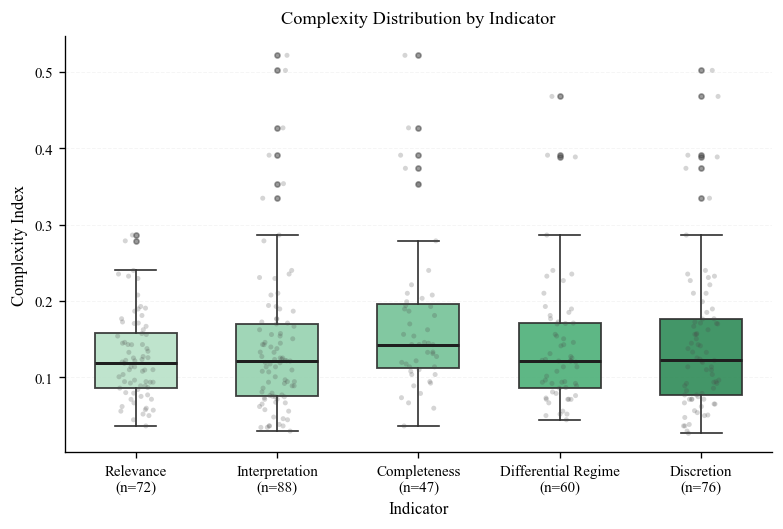

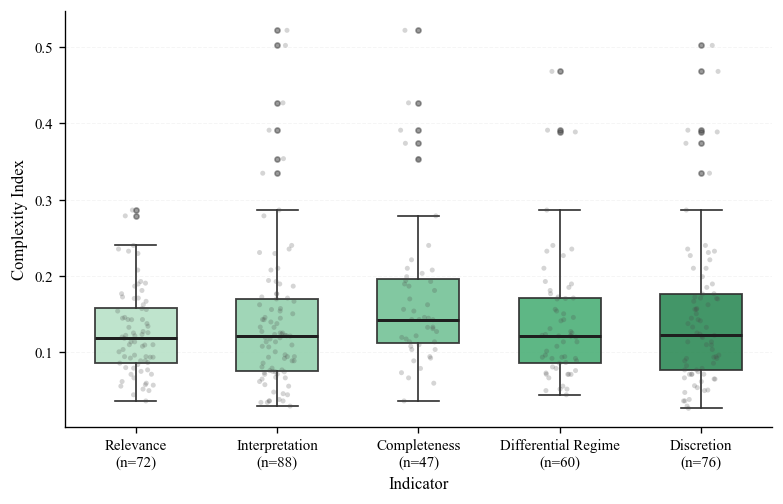

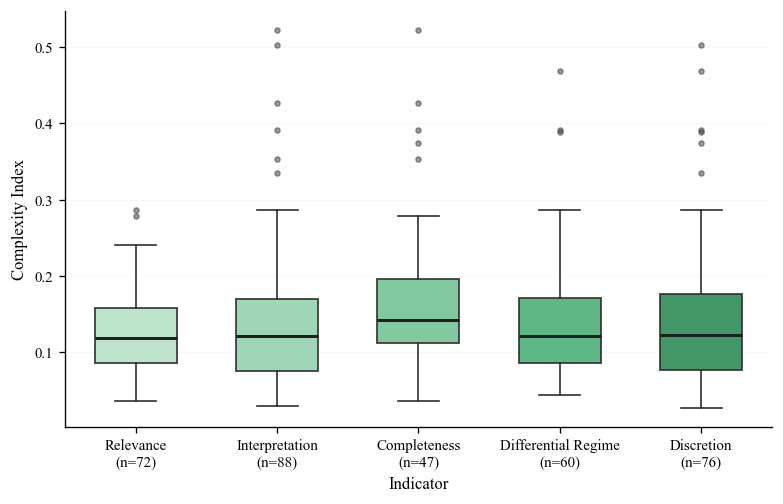

,variant,show_title,show_points,png,svg,pdf
0,with_title,True,True,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
1,without_title,False,True,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
2,clean_minimal,False,False,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...


In [4]:
def save_figure(fig: plt.Figure, stem: str) -> tuple[Path, Path, Path]:
    png = OUTPUT_DIR / f"{stem}.png"
    svg = OUTPUT_DIR / f"{stem}.svg"
    pdf = OUTPUT_DIR / f"{stem}.pdf"

    fig.savefig(png, dpi=EXPORT_DPI, bbox_inches="tight")
    fig.savefig(svg, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    return png, svg, pdf


def draw_boxplot(show_title: bool, show_points: bool, seed: int = RNG_SEED) -> plt.Figure:
    rng = np.random.default_rng(seed)

    fig, ax = plt.subplots(figsize=FIGSIZE)

    order = ORDER
    groups = [plot_df.loc[plot_df["indicator"] == k, "complexity_index"].to_numpy() for k in order]

    bp = ax.boxplot(
        groups,
        positions=np.arange(len(order)),
        widths=0.58,
        patch_artist=True,
        showfliers=True,
        boxprops=dict(edgecolor=BOX_EDGE, linewidth=1.1),
        medianprops=dict(color=MEDIAN_COLOR, linewidth=1.8),
        whiskerprops=dict(color=BOX_EDGE, linewidth=1.0),
        capprops=dict(color=BOX_EDGE, linewidth=1.0),
        flierprops=dict(marker='o', markersize=3.0, markerfacecolor=POINT_COLOR, markeredgecolor=POINT_COLOR, alpha=0.55),
    )

    for box, k in zip(bp["boxes"], order):
        box.set_facecolor(PALETTE[k])
        box.set_alpha(0.90)

    if show_points:
        for i, k in enumerate(order):
            vals = plot_df.loc[plot_df["indicator"] == k, "complexity_index"].to_numpy()
            xj = i + rng.uniform(-0.13, 0.13, size=len(vals))
            ax.scatter(xj, vals, s=9, color=POINT_COLOR, alpha=0.23, edgecolors="none", zorder=2)

    label_map = {k: DISPLAY_NAMES[k] for k in order}
    xticklabels = [label_map[k] for k in order]

    ax.set_xticks(np.arange(len(order)))
    ax.set_xticklabels(xticklabels)
    ax.set_xlabel("Indicator")
    ax.set_ylabel("Complexity Index")

    if show_title:
        ax.set_title("Complexity Distribution by Indicator", pad=8)

    ax.grid(axis="y", alpha=0.12, linestyle="--", linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return fig


export_rows = []
for cfg in STYLE_VARIANTS:
    variant = cfg["name"]
    fig = draw_boxplot(show_title=cfg["show_title"], show_points=cfg["show_points"])

    stem = f"paper_complexity_by_indicator__{variant}"
    png_path, svg_path, pdf_path = save_figure(fig, stem)
    plt.show()
    plt.close(fig)

    export_rows.append({
        "variant": variant,
        "show_title": cfg["show_title"],
        "show_points": cfg["show_points"],
        "png": str(png_path),
        "svg": str(svg_path),
        "pdf": str(pdf_path),
    })

export_log = pd.DataFrame(export_rows)
display(export_log)


## 5) Metadata Export


In [5]:
meta = pd.DataFrame([
    {
        "complexity_dir": str(COMPLEXITY_DIR),
        "rows_total": int(len(plot_df)),
        "indicators": "; ".join(DISPLAY_NAMES[k] for k in ORDER),
        "export_prefix": "paper_complexity_by_indicator__*",
    }
])

meta_path = OUTPUT_DIR / "paper_complexity_by_indicator__metadata.csv"
log_path = OUTPUT_DIR / "paper_complexity_by_indicator__export_log.csv"

meta.to_csv(meta_path, index=False)
export_log.to_csv(log_path, index=False)

print("Saved metadata:", meta_path)
print("Saved export log:", log_path)


Saved metadata: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_by_indicator__metadata.csv
Saved export log: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\complexity\paper_complexity_by_indicator__export_log.csv
